# Model Interpretability

## Objective
Understand how the traind Random Forest model make predictions and identify which patient characteristics contribute most to heart disease risk

## Import Libraries

In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split

## Load Model

In [3]:
model = joblib.load(
    "../models/random_forest_best.pkl"
)

## Data Preperation

### Load Data

In [4]:
df = pd.read_csv("../data/processed/cleveland_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


### Data Split

In [6]:
X = df.drop(columns="target")

y = df["target"]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

## Feature Importance

In [8]:
## Retrive Feature importance (Random Forest Already calculates it)
feature_importance = (
    model.named_steps["model"]
    .feature_importances_
)

## Create DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})


## Sort DataFrame
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)
importance_df

,Feature,Importance
6,restecg,0.132789
3,trestbps,0.126311
12,thal,0.121837
4,chol,0.096782
11,ca,0.094794
2,cp,0.092738
0,age,0.090479
1,sex,0.071803
9,oldpeak,0.060252
5,fbs,0.040932


## Plot

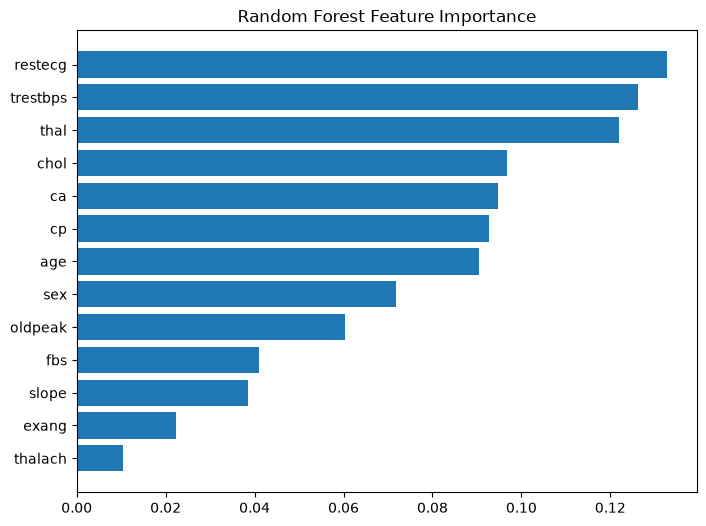

In [9]:
plt.figure(figsize=(8,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.show()

## Permutation Importance
- Tree importance can be biase

In [11]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)


perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    "Importance",
    ascending=False
)

perm_df

,Feature,Importance
11,ca,6.967213e-02
2,cp,5.737705e-02
12,thal,4.672131e-02
7,thalach,4.180328e-02
8,exang,3.032787e-02
9,oldpeak,2.704918e-02
0,age,2.131148e-02
4,chol,1.065574e-02
10,slope,1.065574e-02
1,sex,8.196721e-03


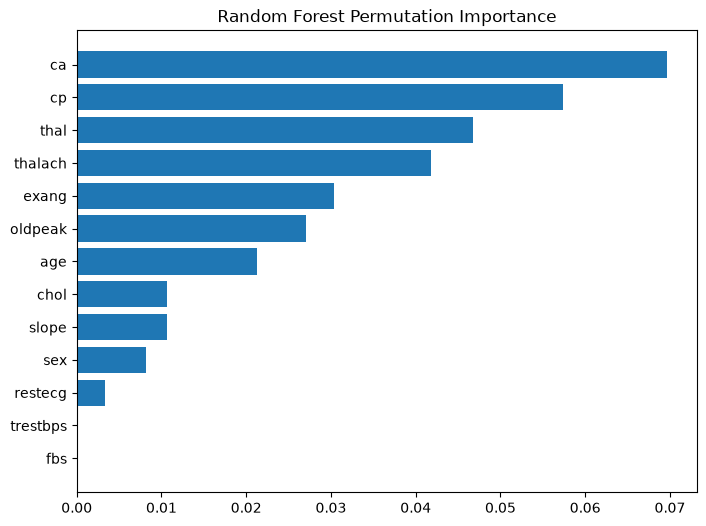

In [12]:
plt.figure(figsize=(8,6))

plt.barh(
    perm_df["Feature"],
    perm_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Permutation Importance")

plt.show()

## Inspect Prediction

In [15]:
sample = X_test.iloc[:5]

predictions = model.predict(sample)

probabilities = model.predict_proba(sample)

prediction_df = sample.copy()

prediction_df["Prediction"] = predictions

prediction_df["Probability"] = probabilities[:,1]

In [16]:
prediction_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Prediction,Probability
219,59,1,4,138,271,0,2,182,0,0.0,1,0,3,0,0.25
271,66,1,4,160,228,0,2,138,0,2.3,1,0,6,1,0.74
89,51,0,3,130,256,0,2,149,0,0.5,1,0,3,0,0.06
101,34,1,1,118,182,0,2,174,0,0.0,1,0,3,0,0.10
67,54,1,3,150,232,0,2,165,0,1.6,1,0,7,0,0.41


Here's a shorter and simpler version:

### Engineering Insights

Two methods were used to understand how the Random Forest model makes predictions: **built-in feature importance** and **permutation importance**.

The rankings were slightly different, but both methods identified **ca** and **thal** as the most important features. This suggests the model is using meaningful patterns rather than random data. The difference in rankings is normal because each method measures feature importance differently.

### Medical Insights

The important features are also well known in heart disease diagnosis:

* **ca** – Number of major blood vessels affected.
* **thal** – Results of the thallium stress test.
* **cp** – Type of chest pain.
* **thalach** – Maximum heart rate during exercise.
* **exang** – Exercise-induced chest pain.

The model focusing on these features shows that its predictions are consistent with medical knowledge. However, these results show associations, not cause-and-effect.

### Conclusion

The feature importance analysis helps explain how the Random Forest model predicts heart disease. Both methods highlighted important clinical features, especially **ca** and **thal**, making the model more transparent and trustworthy. The model can support clinical decision-making but should not replace a doctor's judgment.
